# Counts Analysis

Notebook para carregar os arquivos processados de `published_counts`, plotar as series log-log e ajustar os coeficientes `d_f`, `d_min`, `d_hull` e `d_hull_ext`.

In [29]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from src.CountsAnalysis import (
    OBSERVABLES,
    processed_counts_index,
    filter_index,
    read_counts_file,
    fit_samples,
    fit_all_observables,
    summarize_fits,
    plot_sample,
    plot_mean,
    rounded_value_error,
    
)

plt.style.use("properties.mplstyle") if Path("properties.mplstyle").exists() else None

## Datasets Processados

In [30]:
df_index = processed_counts_index("../SOP_data/published_counts")
df_index

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,path,n_count_files,n_samples,n_legacy_d_min_fallback_samples,last_run_new_samples,last_run_updated_samples,raw_count_files_this_run,existing_processed_files
0,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,37,0,0,37,8,1
1,bond,1,2,16384,0.064613,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,7,28,0,0,28,7,1
2,bond,1,2,16384,0.065300,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,19,0,0,19,8,1
3,bond,1,2,16384,0.065988,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,24,0,0,24,8,1
4,bond,1,2,16384,0.066675,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,31,0,0,31,9,1
5,bond,1,2,16384,0.067363,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,6,19,0,0,19,6,1
6,bond,1,2,16384,0.068050,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,50,0,0,50,9,1
7,bond,1,2,16384,0.068737,0.01,1.0,1.0,0.2,0.8,/home/light/Documents/self_organization_percol...,1,1,1,0,0,0,1
8,bond,1,2,16384,0.069425,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,49,0,0,49,9,1
9,bond,1,2,16384,0.070112,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,52,0,0,52,9,1


## Escolha Do Conjunto

In [31]:
selection = filter_index(
    df_index,
    type_percolation="bond",
    dim=2,
    L=16384,
    c=0.01,
    rho=1.0,
    P0=0.2,
    p0=0.8,
)

selection

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,path,n_count_files,n_samples,n_legacy_d_min_fallback_samples,last_run_new_samples,last_run_updated_samples,raw_count_files_this_run,existing_processed_files
0,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,37,0,0,37,8,1
1,bond,1,2,16384,0.064613,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,7,28,0,0,28,7,1
2,bond,1,2,16384,0.065300,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,19,0,0,19,8,1
3,bond,1,2,16384,0.065988,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,8,24,0,0,24,8,1
4,bond,1,2,16384,0.066675,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,31,0,0,31,9,1
5,bond,1,2,16384,0.067363,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,6,19,0,0,19,6,1
6,bond,1,2,16384,0.068050,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,50,0,0,50,9,1
7,bond,1,2,16384,0.068737,0.01,1.0,1.0,0.2,0.8,/home/light/Documents/self_organization_percol...,1,1,1,0,0,0,1
8,bond,1,2,16384,0.069425,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,49,0,0,49,9,1
9,bond,1,2,16384,0.070112,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,52,0,0,52,9,1


In [34]:
dataset_path = Path(selection.iloc[0]["path"])
payload = read_counts_file(dataset_path)

dataset_path, payload["meta"]

(PosixPath('/home/light/Documents/self_organization_percolation/SOP_data/published_counts/bond_percolation/dim_2/L_16384/fT_0.06392565/c_0.01/rho_1/counts_P0_0.2_p0_0.8.json'),
 {'type_percolation': 'bond',
  'num_colors': 1,
  'dim': 2,
  'L': 16384,
  'f_T': 0.06392565,
  'c': 0.01,
  'rho': 1.0,
  'gap_over_L': 1.5,
  'P0': 0.2,
  'p0': 0.8,
  'relations': {'d_f': 'N_bulk ~ (L_over_epsilon)^d_f',
   'd_hull': 'N_hull ~ (L_over_epsilon)^d_hull',
   'd_hull_ext': 'N_hull_ext ~ (L_over_epsilon)^d_hull_ext',
   'd_min': 'ell ~ r^d_min'},
  'd_min_note': 'No L rescaling is applied to d_min. The default processed series uses ell_min over all bins. ell_mean, ell_max and truncated flags are kept only as diagnostics.',
  'n_count_files': 8,
  'n_samples': 37,
  'n_legacy_d_min_fallback_samples': 0,
  'last_run_new_samples': 0,
  'last_run_updated_samples': 37})

## Plot De Uma Rede/Amostra

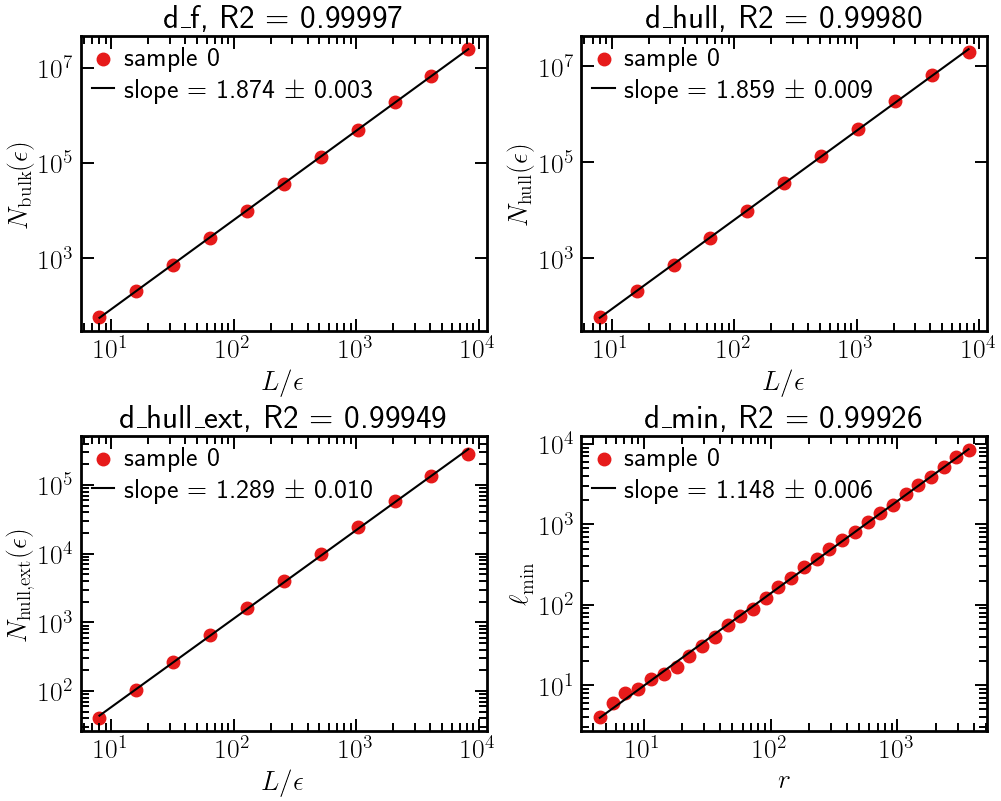

In [35]:
sample_index = 0

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, observable in zip(axes.ravel(), OBSERVABLES):
    _, fit = plot_sample(payload, observable, sample_index=sample_index, ax=ax)
    slope_text = rounded_value_error(fit["slope"], fit["slope_err"])
    ax.set_title(f"{observable}, R2 = {fit['r2']:.5f}")

plt.show()


## Ajustes Por Amostra

In [36]:
fits = fit_all_observables(payload)
fits.head()

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,...,seed,x_name,y_name,ignore_truncated,slope,slope_err,intercept,intercept_err,r2,n_points
0,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.873749,0.003188,0.132018,0.019012,0.999974,11
1,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.866059,0.004566,0.057409,0.027228,0.999946,11
2,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.858228,0.006329,0.144518,0.037738,0.999896,11
3,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.844501,0.007054,0.122074,0.042059,0.999868,11
4,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.845727,0.008376,-0.261557,0.049944,0.999815,11


## Diagnostico Do d_min


In [37]:
dmin_default = fit_samples(payload, "d_min")
dmin_mean = fit_samples(payload, "d_min", y_variant="ell_mean")

pd.concat([
    summarize_fits(dmin_default).assign(estimator="default_ell_min_todos_bins"),
    summarize_fits(dmin_mean).assign(estimator="ell_mean_todos_bins"),
], ignore_index=True)[["estimator", "observable", "slope_mean", "slope_std", "slope_sem", "r2_mean", "n_samples"]]


,estimator,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,default_ell_min_todos_bins,d_min,1.137284,0.005189,0.000853,0.999615,37
1,ell_mean_todos_bins,d_min,0.813555,0.052705,0.008665,0.993255,37


In [38]:
summary = summarize_fits(fits)
summary

,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,d_f,1.862046,0.011024,0.001812,0.999927,37
1,d_hull,1.847741,0.010992,0.001807,0.999787,37
2,d_hull_ext,1.299399,0.010678,0.001755,0.999327,37
3,d_min,1.137284,0.005189,0.000853,0.999615,37


## Controle Da Janela De Ajuste

In [39]:
fit_window = {
    "x_min": None,
    "x_max": None,
}


In [40]:
fits_window = fit_all_observables(payload, **fit_window)
summarize_fits(fits_window)


,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,d_f,1.862046,0.011024,0.001812,0.999927,37
1,d_hull,1.847741,0.010992,0.001807,0.999787,37
2,d_hull_ext,1.299399,0.010678,0.001755,0.999327,37
3,d_min,1.137284,0.005189,0.000853,0.999615,37


## Plot Das Medias Das Series

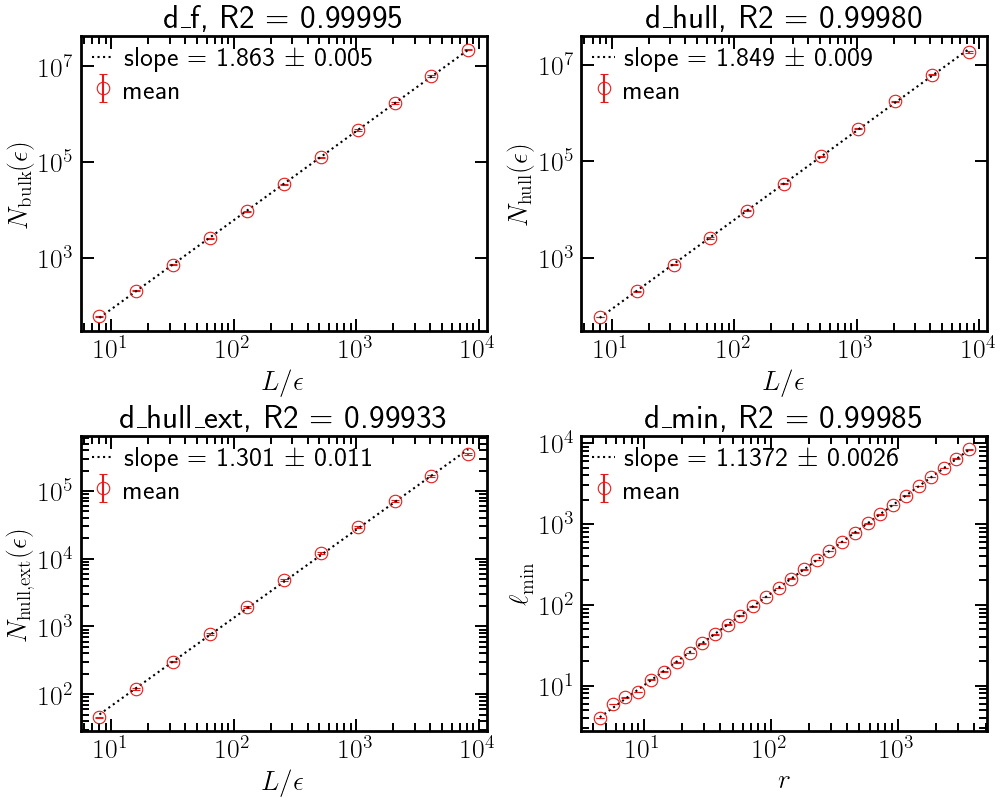

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, observable in zip(axes.ravel(), OBSERVABLES):
    _, fit = plot_mean(payload, observable, ax=ax, **fit_window)
    slope_text = rounded_value_error(fit["slope"], fit["slope_err"])
    ax.set_title(f"{observable}, R2 = {fit['r2']:.5f}")

plt.show()


## Ajustes Em Todos Os Arquivos

In [42]:
all_fits = []
for path in df_index["path"]:
    data = read_counts_file(path)
    all_fits.append(fit_all_observables(data, **fit_window))

all_fits = pd.concat(all_fits, ignore_index=True)
all_fits.head()

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,...,seed,x_name,y_name,ignore_truncated,slope,slope_err,intercept,intercept_err,r2,n_points
0,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.873749,0.003188,0.132018,0.019012,0.999974,11
1,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.866059,0.004566,0.057409,0.027228,0.999946,11
2,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.858228,0.006329,0.144518,0.037738,0.999896,11
3,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.844501,0.007054,0.122074,0.042059,0.999868,11
4,bond,1,2,16384,0.063926,0.01,1.0,1.5,0.2,0.8,...,1048153267,L_over_epsilon,N_bulk,False,1.845727,0.008376,-0.261557,0.049944,0.999815,11


In [43]:
all_summary = (
    all_fits
    .groupby(["type_percolation", "dim", "L", "f_T", "c", "rho", "P0", "p0", "observable"], as_index=False)
    .agg(
        slope_mean=("slope", "mean"),
        slope_std=("slope", "std"),
        slope_sem=("slope", lambda x: x.std() / np.sqrt(x.notna().sum())),
        r2_mean=("r2", "mean"),
        n_samples=("slope", "count"),
    )
)

all_summary

,type_percolation,dim,L,f_T,c,rho,P0,p0,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,bond,2,16384,0.063926,0.01,1.0,0.2,0.8,d_f,1.862046,0.011024,0.001812,0.999927,37
1,bond,2,16384,0.063926,0.01,1.0,0.2,0.8,d_hull,1.847741,0.010992,0.001807,0.999787,37
2,bond,2,16384,0.063926,0.01,1.0,0.2,0.8,d_hull_ext,1.299399,0.010678,0.001755,0.999327,37
3,bond,2,16384,0.063926,0.01,1.0,0.2,0.8,d_min,1.137284,0.005189,0.000853,0.999615,37
4,bond,2,16384,0.064613,0.01,1.0,0.2,0.8,d_f,1.861453,0.014654,0.002769,0.999914,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,node,2,16384,0.081375,0.01,1.0,0.2,0.8,d_min,0.890688,0.067103,0.009490,0.990595,50
120,node,2,16384,0.084630,0.01,1.0,0.2,0.8,d_f,1.882554,0.008816,0.001247,0.999929,50
121,node,2,16384,0.084630,0.01,1.0,0.2,0.8,d_hull,1.882400,0.008816,0.001247,0.999927,50
122,node,2,16384,0.084630,0.01,1.0,0.2,0.8,d_hull_ext,1.319895,0.008164,0.001155,0.999839,50


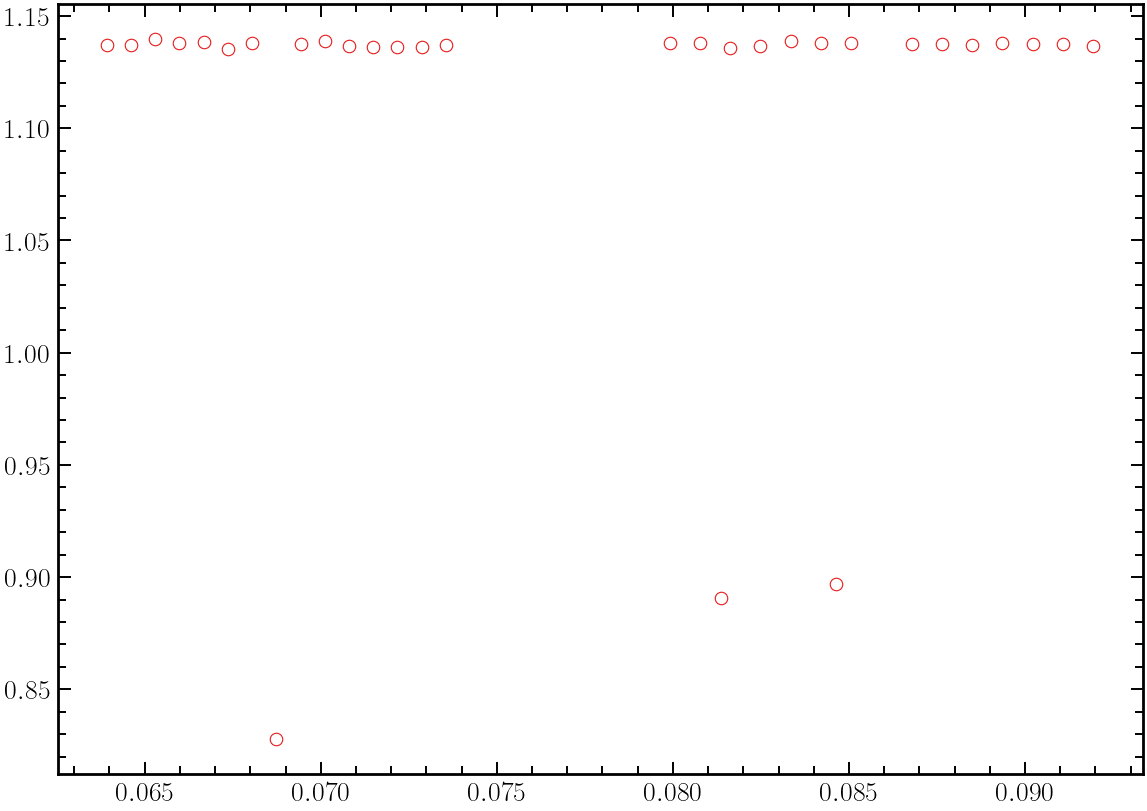

In [ ]:
#all_summary[all_summary['observable']=='d_f']['slope_mean']
df_sub = all_summary[all_summary['observable']=='d_min']
d_f = df_sub['slope_mean']
f_T = df_sub['f_T']
#df_theorical = 1.895833
plt.plot(f_T, d_f,'o')
#plt.axhline(y=df_theorical)
plt.show()